<a href="https://colab.research.google.com/github/Samyak523/plant_disease_detection/blob/main/crop_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Disease Detection

In [ ]:
import kagglehub
vipoooool_new_plant_diseases_dataset_path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Data source import complete.


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn


from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models


In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

In [ ]:
for dirpaths, dirnames, filenames in os.walk(vipoooool_new_plant_diseases_dataset_path):
    print(f'There are {len(dirnames)} directories and {len(filenames)} files in {dirpaths}')


In [ ]:
path = Path(os.path.join(vipoooool_new_plant_diseases_dataset_path, 'New Plant Diseases Dataset(Augmented)', 'New Plant Diseases Dataset(Augmented)'))

In [ ]:
os.listdir(os.path.join(vipoooool_new_plant_diseases_dataset_path, 'test', 'test'))

In [ ]:
train_path = os.path.join(path,'train')
val_path = os.path.join(path,'valid')
test_path = Path(os.path.join(vipoooool_new_plant_diseases_dataset_path, 'test', 'test'))

In [ ]:
train_path_list = list(path.glob('train/*/*.JPG'))

In [ ]:
test_path_list = list(test_path.glob('*.JPG'))

In [ ]:
len(train_path_list),len(test_path_list)

In [ ]:
random_image_path = random.choice(train_path_list)
random_image_path
img = Image.open(random_image_path)

In [ ]:
image_class = random_image_path.parent.stem
image_class

In [ ]:
img_as_array = np.asarray(img)
img_as_tensor = torch.tensor(img_as_array)/255

In [ ]:
img_as_tensor

In [ ]:
img = Image.open(random_image_path)
print(f'width: {img.width} height: {img.height}')
plt.imshow(img_as_tensor)
plt.axis(False)


In [ ]:
data_transform = transforms.Compose([
    transforms.ToTensor()
    ])

In [ ]:
train_data = datasets.ImageFolder(root=train_path,
                                  transform=data_transform,
                                  target_transform=None
                                  )

val_data = datasets.ImageFolder(root=val_path,
                                transform=data_transform)

In [ ]:
train_data

In [ ]:
image_class = random_image_path.parent.stem
image_class

In [ ]:
image_class = random_image_path.parent.stem
image_class

In [ ]:
img_as_array = np.asarray(img)
img_as_tensor = torch.tensor(img_as_array)/255

In [ ]:
img_as_tensor

In [ ]:
img = Image.open(random_image_path)
print(f'width: {img.width} height: {img.height}')
plt.imshow(img_as_tensor)
plt.axis(False)

In [ ]:
image_class = random_image_path.parent.stem
image_class

In [ ]:
img_as_array = np.asarray(img)
img_as_tensor = torch.tensor(img_as_array)/255

In [ ]:
img_as_tensor

width: 256 height: 256


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

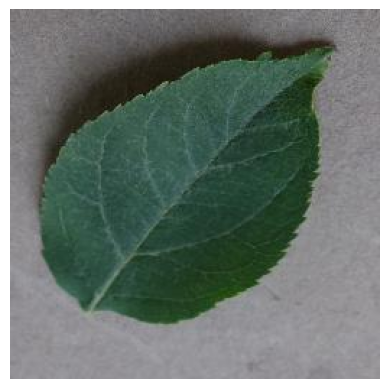

In [ ]:
img = Image.open(random_image_path)
print(f'width: {img.width} height: {img.height}')
plt.imshow(img_as_tensor)
plt.axis(False)

In [ ]:
val_data

Dataset ImageFolder
    Number of datapoints: 17572
    Root location: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [ ]:

classes = train_data.classes
len(classes)

38

In [ ]:
cpu_count = os.cpu_count()

In [ ]:
len(train_data)

70295

In [ ]:
BATCH_SIZE = 24

train_loader = DataLoader(dataset=train_data,
                          batch_size=BATCH_SIZE,
                          num_workers=cpu_count,
                          shuffle=True
                          )

val_loader = DataLoader(dataset=val_data,
                          batch_size=BATCH_SIZE,
                          num_workers=cpu_count,
                          shuffle=True
                          )



In [ ]:
img, label = next(iter(train_loader))

In [ ]:
img.shape, label.shape

(torch.Size([24, 3, 256, 256]), torch.Size([24]))

In [ ]:
model_0 = models.efficientnet_b3(weights=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
model_0.classifier.append(nn.Linear(1000,len(classes)))

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1000, bias=True)
  (2): Linear(in_features=1000, out_features=38, bias=True)
)

In [ ]:
model_0

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [ ]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
device

'cuda'

In [ ]:
model_0.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr = 0.001)

In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):

  model_0.train()

  cost = 0
  train_acc = 0
  valid_acc = 0

  print(f'Epoch: {epoch}')

  for X,y in train_loader:

    X,y = X.to(device), y.to(device)

    y_pred = model_0(X)

    loss = loss_fn(y_pred,y)

    cost+=loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = y_pred.argmax(dim=1)

    train_acc += 100*(y_pred_class == y).sum().item()/len(y_pred)

  train_acc/=len(train_loader)
  cost/=len(train_loader)

  model_0.eval()

  with torch.inference_mode():

    for X,y in val_loader:

      X,y = X.to(device), y.to(device)

      test_pred = model_0(X)

      test_pred_class = test_pred.argmax(dim=1)

      valid_acc += 100*(test_pred_class == y).sum().item()/len(y)

    valid_acc/=len(val_loader)

  print(f"Cost: {cost:.4f} | Train Acc: {train_acc:.2f} | Val Acc: {valid_acc:.2f}")

In [ ]:
from datetime import datetime

future_date = datetime.now()
time = future_date.strftime("%Y-%m-%d_%H:%M:%S")

In [ ]:
from pathlib import Path


MODEL_PATH = Path("/content/gdrive/MyDrive/Models/crop_disease_detection_cnn")
MODEL_PATH.mkdir(parents=True, exist_ok=True)


MODEL_NAME = f"crop_disease_detection_model_{time}.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME


torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)
print(f"Saved model to: {MODEL_SAVE_PATH}")



## Loading the trained model

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn


from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

In [ ]:
MODEL_PATH = Path("/content/gdrive/MyDrive/Models/crop_disease_detection_cnn")

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
files = os.listdir(MODEL_PATH)
files.sort(reverse=True)
files

In [ ]:
MODEL_SAVE_PATH = os.path.join(MODEL_PATH,files[0])

In [ ]:
loaded_model = models.efficientnet_b3()
loaded_model.classifier.append(nn.Linear(1000,38))

In [ ]:
loaded_model.load_state_dict(torch.load(f = MODEL_SAVE_PATH, map_location= device))
loaded_model.to(device)

In [ ]:
test_path = Path('/kaggle/input/new-plant-diseases-dataset/test/test')
test_path_list = list(test_path.glob('*.JPG'))

In [ ]:
test_path_list

In [ ]:
loaded_model.eval()
with torch.inference_mode():

  plt.figure(figsize=(20, 60))

  for x in range(len(test_path_list)):

    img = torch.tensor(np.asarray(Image.open(test_path_list[x])))/255.
    plt.subplot(11,3,x+1)
    plt.imshow(img)

    img = img.permute(2,1,0).unsqueeze(dim=0)

    pred_logits = loaded_model(img.to(device))
    pred_class = classes[pred_logits.argmax(dim=1).item()]

    plt.title(f'File: {str(test_path_list[x]).split('/')[-1]}\nPrediction: {pred_class}',fontsize=10)
    plt.axis(False)